# Stage 5 - Customer Vectors and Similarity

This stage turns customers into numeric vectors and finds, for a new customer, the
most similar **historical customers who stayed**. The idea: if we can point to real
customers a lot like this one who did not churn, the retention team has concrete,
relatable evidence to work from.

Two key rules, both enforced in `src/similarity/`:

1. Vectors are built with the **same fitted preprocessor** as the model, and they
   **exclude** the customer ID, the churn label, and the model's prediction - so the
   similarity space has no target leakage.
2. Similarity is measured in the **full processed vector space** (46 features). The
   2D map at the end is for viewing only.

All logic lives in `src/similarity/`; this notebook calls it.

In [1]:
import sys
from pathlib import Path

here = Path.cwd()
project_root = here if (here / "src").exists() else here.parent
sys.path.insert(0, str(project_root))

import warnings

import pandas as pd

from src.config import DATA_PROCESSED_DIR, MODELS_DIR, FIGURES_DIR
from src.features.preprocessor import load_preprocessor
from src.similarity.vectorizer import build_customer_vectors, vectorize_one
from src.similarity.search import find_similar_retained, compare_characteristics
from src.similarity import projector

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

customers = pd.read_csv(DATA_PROCESSED_DIR / "telco_clean.csv")
preprocessor = load_preprocessor(MODELS_DIR / "preprocessor.joblib")

## 1. Vectorise all historical customers

In [2]:
customer_vectors = build_customer_vectors(preprocessor, customers)

print("Vector matrix shape:", customer_vectors.vectors.shape)
print("Customers who stayed:", int(customer_vectors.stayed.sum()))
print("Customers who churned:", int((~customer_vectors.stayed).sum()))

Vector matrix shape: (7043, 46)
Customers who stayed: 5174
Customers who churned: 1869


**Conclusion:** Every one of the 7,043 historical customers is now a 46-feature
vector, built by the same preprocessor the model uses. The churn outcome and
customer ID are stored **next to** the vectors as lookup data, not inside them, so
the similarity space cannot peek at who churned.

## 2. A new customer to analyse

In [3]:
# Example: a new customer with a higher-risk profile (short tenure, fibre-optic
# internet, month-to-month contract, electronic-check payment, no support add-ons).
new_customer = pd.DataFrame(
    [
        {
            "gender": "Female", "SeniorCitizen": 0, "Partner": "No", "Dependents": "No",
            "tenure": 2, "PhoneService": "Yes", "MultipleLines": "No",
            "InternetService": "Fiber optic", "OnlineSecurity": "No", "OnlineBackup": "No",
            "DeviceProtection": "No", "TechSupport": "No", "StreamingTV": "Yes",
            "StreamingMovies": "Yes", "Contract": "Month-to-month", "PaperlessBilling": "Yes",
            "PaymentMethod": "Electronic check", "MonthlyCharges": 95.0, "TotalCharges": 190.0,
        }
    ]
)

new_vector = vectorize_one(preprocessor, new_customer)
print("New customer vector shape:", new_vector.shape)
new_customer

New customer vector shape: (1, 46)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.0,190.0


## 3. Find the most similar retained customers

In [4]:
neighbors = find_similar_retained(customer_vectors, new_vector, top_k=5)
neighbors.round(3)

,row_index,customer_id,similarity
0,2238,1393-IMKZG,0.949
1,1903,3318-NMQXL,0.948
2,5354,4273-MBHYA,0.947
3,5140,7577-SWIFR,0.947
4,293,4847-TAJYI,0.945


**Conclusion:** The five closest customers are all customers who **stayed**, with
cosine similarity around **0.95** - very close matches in the full feature space.
These are the real, comparable customers the retention plan in Stage 6 will draw
on. Similarity is computed across all 46 features, not the 2D map.

## 4. Shared characteristics and important differences

In [5]:
# Compare the new customer with the single closest retained customer.
closest_row = int(neighbors.iloc[0]["row_index"])
closest_features = customer_vectors.raw_features.iloc[closest_row]

comparison = compare_characteristics(new_customer, closest_features)

print("Most similar retained customer:", neighbors.iloc[0]["customer_id"])
print()
print("Shared characteristics:")
for item in comparison["shared"]:
    print(f"  = {item['feature']}: {item['new_value']}")
print()
print("Important differences (new vs neighbor):")
for item in comparison["different"]:
    print(f"  ~ {item['feature']}: {item['new_value']}  vs  {item['neighbor_value']}")

Most similar retained customer: 1393-IMKZG

Shared characteristics:
  = gender: Female
  = SeniorCitizen: 0
  = Partner: No
  = Dependents: No
  = PhoneService: Yes
  = MultipleLines: No
  = InternetService: Fiber optic
  = OnlineSecurity: No
  = OnlineBackup: No
  = DeviceProtection: No
  = StreamingTV: Yes
  = StreamingMovies: Yes
  = Contract: Month-to-month
  = PaperlessBilling: Yes
  = PaymentMethod: Electronic check
  = MonthlyCharges: 95.0

Important differences (new vs neighbor):
  ~ TechSupport: No  vs  Yes
  ~ tenure: 2.0  vs  1.0
  ~ TotalCharges: 190.0  vs  95.85


**Conclusion:** The new customer and this retained customer share most of their
profile (same contract type, payment method, internet service, lack of support
add-ons, and so on). The few differences - mainly the neighbor's slightly longer
relationship and a couple of service details - are the kind of clues Stage 6 will
use when suggesting what might help retain this customer. We describe these as
**shared traits**, not proof that any single trait caused the neighbor to stay.

## 5. The 2D customer map

Variance captured by the 2 components: [0.285, 0.189]  sum: 0.474


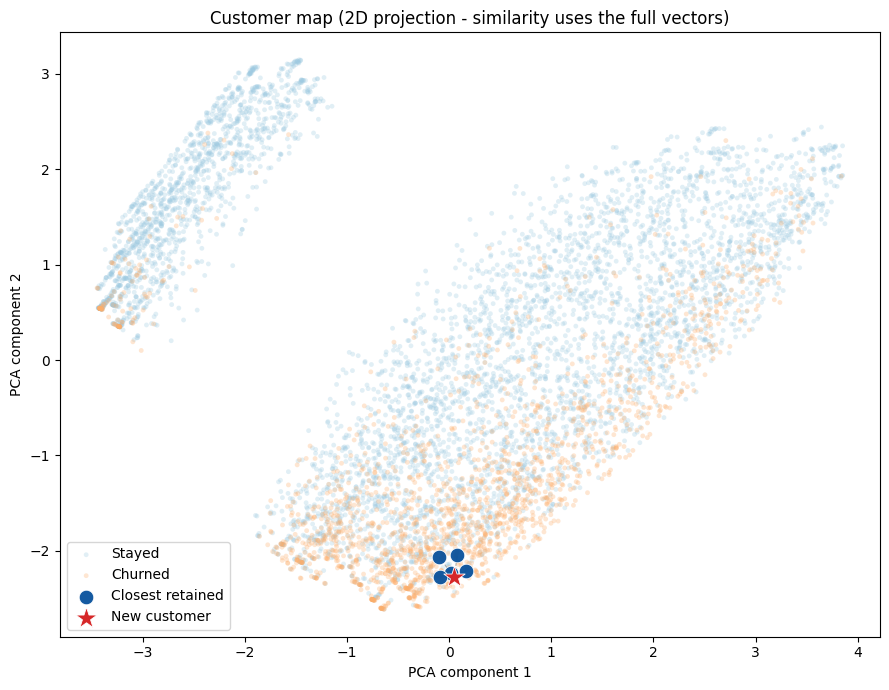

In [6]:
fitted_projector = projector.fit_projector(customer_vectors.vectors)
variance = fitted_projector.explained_variance_ratio_[:2]
print("Variance captured by the 2 components:", variance.round(3).tolist(), " sum:", round(variance.sum(), 3))

map_data = projector.build_map_data(fitted_projector, customer_vectors, new_vector, neighbors)
fig = projector.plot_customer_map(map_data)
fig.savefig(FIGURES_DIR / "customer_map.png", dpi=120, bbox_inches="tight")

**Conclusion:** The map shows where the new customer (red star) sits among
customers who stayed (light blue) and churned (light orange), with the five closest
retained customers highlighted and linked by dashed lines.

The two PCA components capture only about **47%** of the variance, so the map is an
approximate picture, not the full story. This is exactly why:

> The map is a two-dimensional projection for visualization. Cosine similarity and
> neighbor selection are calculated using the complete processed customer vectors.

The dashboard will render this same map interactively (hover for similarity scores)
using the data assembled here.

## Summary of Stage 5

1. Vectorised all 7,043 customers with the fitted Stage 2 preprocessor; the vectors
   exclude ID, churn, and predictions, so the similarity space is leakage-safe.
2. For a new customer, cosine similarity over the full 46-feature space finds the
   closest customers, filtered to those who **stayed** (similarity ~0.95 here).
3. Reported shared characteristics and important differences against the closest
   retained customer, in plain language and without causal claims.
4. Built a PCA 2D map (new customer, neighbors, stayed, churned) and made clear it
   is a visualization only - similarity always uses the full vectors.

**Next (Stage 6):** combine churn probability, risk factors (Stage 4), and these
similar retained customers into a transparent, carefully worded retention plan.